Importing Libraries ---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

Loading the Dataset ---

In [5]:
df = pd.read_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/online_retail_clean.csv")

Validating the Imported Data ---

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Transaction_ID,InvoiceDate_Clean
0,540642,22730,ALARM CLOCK BAKELIKE IVORY,8,01-10-2011 13:22,3.75,12681,France,30.00,1,01-10-2011 13:22
1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850,United Kingdom,15.30,2,12-01-2010 08:26
2,545056,20724,RED RETROSPOT CHARLOTTE BAG,100,2/27/2011 12:48,0.72,16745,United Kingdom,72.00,3,27-02-2011 12:48
3,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850,United Kingdom,20.34,4,12-01-2010 08:26
4,540642,20750,RED RETROSPOT MINI CASES,2,01-10-2011 13:22,7.95,12681,France,15.90,5,01-10-2011 13:22


In [7]:
df.shape

(397884, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   InvoiceNo          397884 non-null  int64  
 1   StockCode          397884 non-null  object 
 2   Description        397884 non-null  object 
 3   Quantity           397884 non-null  int64  
 4   InvoiceDate        397884 non-null  object 
 5   UnitPrice          397884 non-null  float64
 6   CustomerID         397884 non-null  int64  
 7   Country            397884 non-null  object 
 8   Revenue            397884 non-null  float64
 9   Transaction_ID     397884 non-null  int64  
 10  InvoiceDate_Clean  397884 non-null  object 
dtypes: float64(2), int64(4), object(5)
memory usage: 33.4+ MB


Checking null values ---

In [10]:
df.isnull().sum()

InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID           0
Country              0
Revenue              0
Transaction_ID       0
InvoiceDate_Clean    0
dtype: int64

Converting Date Column ---

In [12]:
df["InvoiceDate_Clean"] = pd.to_datetime(df["InvoiceDate_Clean"], format="%d-%m-%Y %H:%M")

Defining Snapshot Date ---

In [14]:
snapshot_date = df["InvoiceDate_Clean"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-11 17:19:00')

Creating RFM (Recency, Frequency, Monetary Value) Table ---

In [15]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate_Clean": lambda x: (
        snapshot_date - x.max()
    ).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

Renaming the columns ---

In [16]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

Checking the Columns ---

In [17]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,327,1,77183.60
12347,41,7,4310.00
12348,77,4,1797.24
12349,20,1,1757.55
12350,312,1,334.40


In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,106.470954,4.272015,2054.266460
std,115.082161,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,23.000000,1.000000,307.415000
50%,62.000000,2.000000,674.485000
75%,162.750000,5.000000,1661.740000
max,698.000000,209.000000,280206.020000


Saving the RFM Table ---

In [19]:
rfm.to_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/rfm_table.csv")

For Recency ---

In [20]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

For Frequency ---

In [21]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

For Monetary Value ---

In [22]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

Creating RFM Scores ---

In [23]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

Creating Customer Segments ---

In [27]:
def segment_customers(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "OG-Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers ;)"

    elif row["R_Score"] >= 4:
        return "Potential Loyalists ^-^"

    elif row["R_Score"] >= 3:
        return "Promising :)"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk :("

    else:
        return "Lost Customers -_-"

Segmenting ---

In [28]:
rfm["Segment"] = rfm.apply(
    segment_customers,
    axis=1
)

Segment Distribution ---

In [29]:
rfm["Segment"].value_counts()

Segment
OG-Champions               1129
Lost Customers -_-         1069
Loyal Customers ;)          817
At Risk :(                  657
Promising :)                338
Potential Loyalists ^-^     328
Name: count, dtype: int64

Segment Distribution ---

In [30]:
rfm["Segment"].value_counts()

Segment
OG-Champions               1129
Lost Customers -_-         1069
Loyal Customers ;)          817
At Risk :(                  657
Promising :)                338
Potential Loyalists ^-^     328
Name: count, dtype: int64

Segment Revenue Distribution ---

In [31]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)
segment_revenue

Segment
OG-Champions               5855340.360
Loyal Customers ;)         1279602.281
At Risk :(                  949057.531
Lost Customers -_-          500487.521
Promising :)                170357.281
Potential Loyalists ^-^     156562.930
Name: Monetary, dtype: float64

Visualizing this Segment Distribution ---

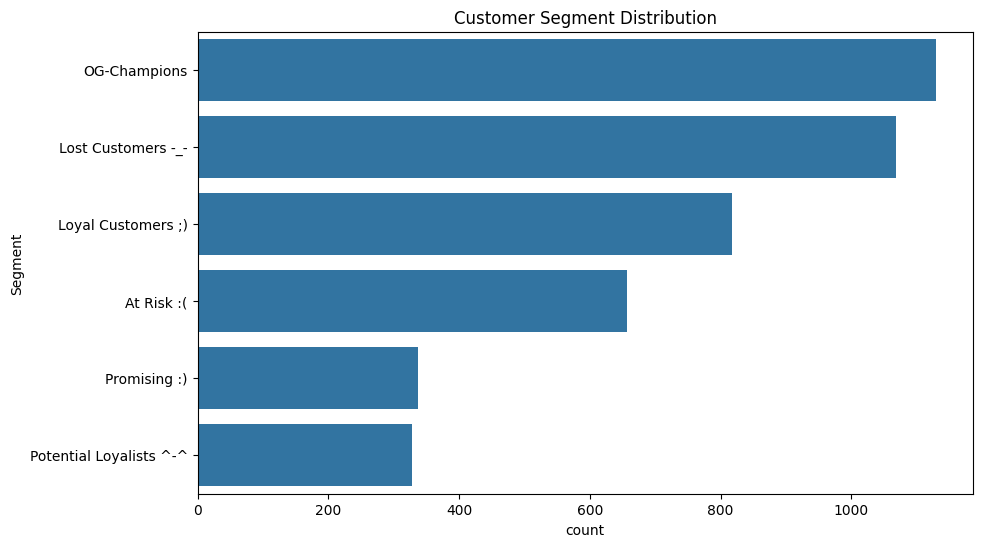

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=rfm["Segment"],
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.show()

Revenue by Segment ---

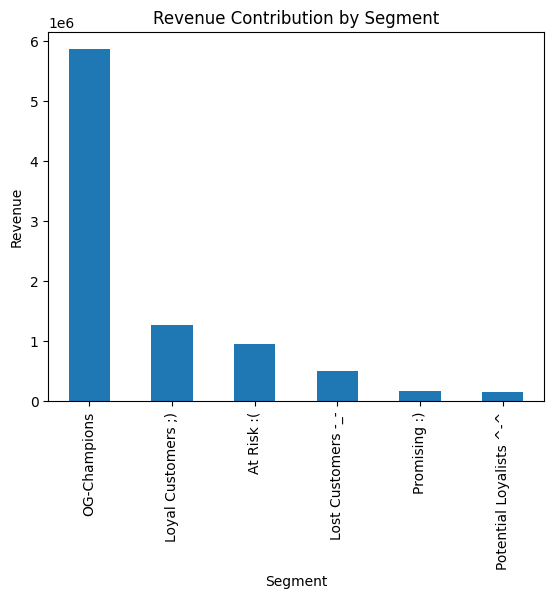

In [33]:
segment_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Segment")
plt.ylabel("Revenue")

plt.show()

Saving this Segmentation Output ---

In [34]:
rfm.to_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/customer_segments.csv")